# Conditional Flow Matching

This notebook is a self-contained example of conditional flow matching. We implement a number of different simulation-free methods for learning flow models. They differ based on the interpolant used and the loss function used to train them.

In this notebook we implement 5 models that can map from a source distribution $q_0$ to a target distribution $q_1$:
* Conditional Flow Matching (CFM)
    * This is equivalent to the basic (non-rectified) formulation of "Flow Straight and Fast: Learning to Generate and Transfer Data with Rectified Flow" [(Liu et al. 2023)](https://openreview.net/forum?id=XVjTT1nw5z)
    * Is similar to "Stochastic Interpolants" [(Albergo et al. 2023)](https://openreview.net/forum?id=li7qeBbCR1t) with a non-variance preserving interpolant.
    * Is similar to "Flow Matching" [(Lipman et al. 2023)](https://openreview.net/forum?id=PqvMRDCJT9t) but conditions on both source and target.
* Optimal Transport CFM (OT-CFM), which directly optimizes for dynamic optimal transport
* Schrödinger Bridge CFM (SB-CFM), which optimizes for Schrödinger Bridge probability paths
* "Building Normalizing Flows with Stochastic Interpolants" [(Albergo et al. 2023)](https://openreview.net/forum?id=li7qeBbCR1t) this corresponds to "VP-CFM" in our README referring to its variance preserving properties.
* "Action Matching: Learning Stochastic Dynamics From Samples" [(Neklyudov et al. 2022)](https://arxiv.org/abs/2210.06662)

Note that this Flow Matching is different from the Generative Flow Network Flow Matching losses. Here we specifically regress against continuous flows, rather than matching inflows and outflows.

In [1]:
import math
import os
import time
from tqdm import tqdm
from numba import cuda
erhgfbrweigbhw

import matplotlib.pyplot as plt
import numpy as np
import ot as pot
import torch
import torchdyn
from torchdyn.core import NeuralODE
from torchdyn.datasets import generate_moons

from torchcfm.conditional_flow_matching import *
from torchcfm.models.models import *
from torchcfm.utils import *

savedir = "models/8gaussian-moons"
os.makedirs(savedir, exist_ok=True)

/pscratch/sd/r/rmastand/torchcfm/lib/python3.10/site-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)


In [2]:
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pickle

epsilon = 1e-12
def logit_transform(x, all_min, all_max, cushion ):
    
    x_norm = (x-all_min)/(all_max-all_min)
    x_norm = (1.0 - 2.0*cushion)*x_norm + cushion
    logit_arguments = (x_norm/(1.0-x_norm+epsilon)) + epsilon
    
    num_invalid_entries = sum(logit_arguments <= 0)
    if num_invalid_entries > 0:
        print("Invalid log. Try again with larger cushion")
        return None
    else:
        logit = np.log(x_norm/(1.0-x_norm+epsilon) + epsilon)
        return logit



def preprocess_data(X, flow_training_dir):

    minmax_scaler = MinMaxScaler()
    standard_scaler = StandardScaler()
        
    X_preproc = minmax_scaler.fit_transform(X)
    for i in range(X.shape[1]):
        X_preproc[:,i] = logit_transform(X_preproc[:,i], 0.0, 1.0, 0.0)
    X_preproc = standard_scaler.fit_transform(X_preproc)

    with open(f"{flow_training_dir}/minmax", "wb") as ofile:
        pickle.dump(minmax_scaler, ofile)
    with open(f"{flow_training_dir}/standard", "wb") as ofile:
        pickle.dump(standard_scaler, ofile)
        
    return X_preproc

In [3]:
device = cuda.get_current_device()
device.reset()
torch.set_num_threads(2)
device = torch.device( "cuda" if torch.cuda.is_available() else "cpu")

print( "Using device: " + str( device ), flush=True)

Using device: cuda


In [4]:
N_EPOCHS = 50
PLOT_EPOCH_INTERVAL = 5
BATCH_SIZE = 1024
N_BINS = 200
BIN_BOUND = 4
N_SAMPLE = 50000
LEARNING_RATE = 1e-3


In [5]:
class MLP(torch.nn.Module):
    def __init__(self, dim, out_dim=None, w=512, time_varying=False):
        super().__init__()
        self.time_varying = time_varying
        if out_dim is None:
            out_dim = dim
        self.net = torch.nn.Sequential(
            torch.nn.Linear(dim + (1 if time_varying else 0), w),
            torch.nn.SELU(),
            torch.nn.Linear(w, w),
            torch.nn.SELU(),
            torch.nn.Linear(w, w),
            torch.nn.SELU(),
            torch.nn.Linear(w, out_dim),
        )

    def forward(self, x):
        return self.net(x)


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)



In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np


def corner_hist2d(
    X,
    feature_labels,
    bins_dict,
    log_dims=(0, 4),
    title=None,
):
    """
    X : (N, D) array
    """
    D = X.shape[1]
    norm = LogNorm()

    fig, axes = plt.subplots(
        D, D,
        figsize=(2 * D, 2 * D),
        constrained_layout=True,
        sharex="col",
        #sharey="row",
    )

    mappable = None

    for i in range(D):
        for j in range(D):
            ax = axes[j, i]

            if j < i:
                ax.axis("off")
                continue

            if i == j:
                # 1D histogram on the diagonal
                ax.hist(
                    X[:, i],
                    bins=np.linspace(-BIN_BOUND, BIN_BOUND, N_BINS),
                    density=True,
                    histtype = "step",
                )

                if i in log_dims:
                    ax.set_xscale("log")
                ax.set_yscale("log")
                ax.set_yticks([])

            else:
                h = ax.hist2d(
                    X[:, i],
                    X[:, j],
                    bins=[np.linspace(-BIN_BOUND, BIN_BOUND, N_BINS), np.linspace(-BIN_BOUND, BIN_BOUND, N_BINS)],
                    norm=norm,
                    density=True,
                )
                mappable = h[3]

                if i in log_dims:
                    ax.set_xscale("log")
                if j in log_dims:
                    ax.set_yscale("log")

            # y ticks only on left column
            if i != 0:
                ax.tick_params(axis="y", which="both", left=False, labelleft=False)
            
            # x ticks only on bottom row
            if j != D - 1:
                ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)

            

            # labels
            if j == D - 1:
                ax.set_xlabel(feature_labels[i])
            if i == 0 and j != i:
                ax.set_ylabel(feature_labels[j])

    if title is not None:
        fig.suptitle(title, fontsize=16)

    if mappable is not None:
        fig.colorbar(
            mappable,
            ax=axes,
            label="density",
            shrink=0.8,
        )

    plt.subplots_adjust(hspace=0, wspace=0)

    return fig, axes


def plot_data(data_dict):
    fig, ax = plt.subplots(1, N_FEATURES, figsize=(N_FEATURES*5, N_FEATURES))
    for i in range(N_FEATURES):
        for key in data_dict.keys():
            ax[i].hist(data_dict[key][:,i], bins=np.linspace(-BIN_BOUND, BIN_BOUND, N_BINS), density=True, histtype = "step", label = key)
        ax[i].set_title(f"Feature {i}")
        ax[i].set_yscale("log")
    ax[-1].legend()
    return fig, ax

Data shape: (6787500, 5)


(<Figure size 2500x500 with 5 Axes>,
 array([<Axes: title={'center': 'Feature 0'}>,
        <Axes: title={'center': 'Feature 1'}>,
        <Axes: title={'center': 'Feature 2'}>,
        <Axes: title={'center': 'Feature 3'}>,
        <Axes: title={'center': 'Feature 4'}>], dtype=object))

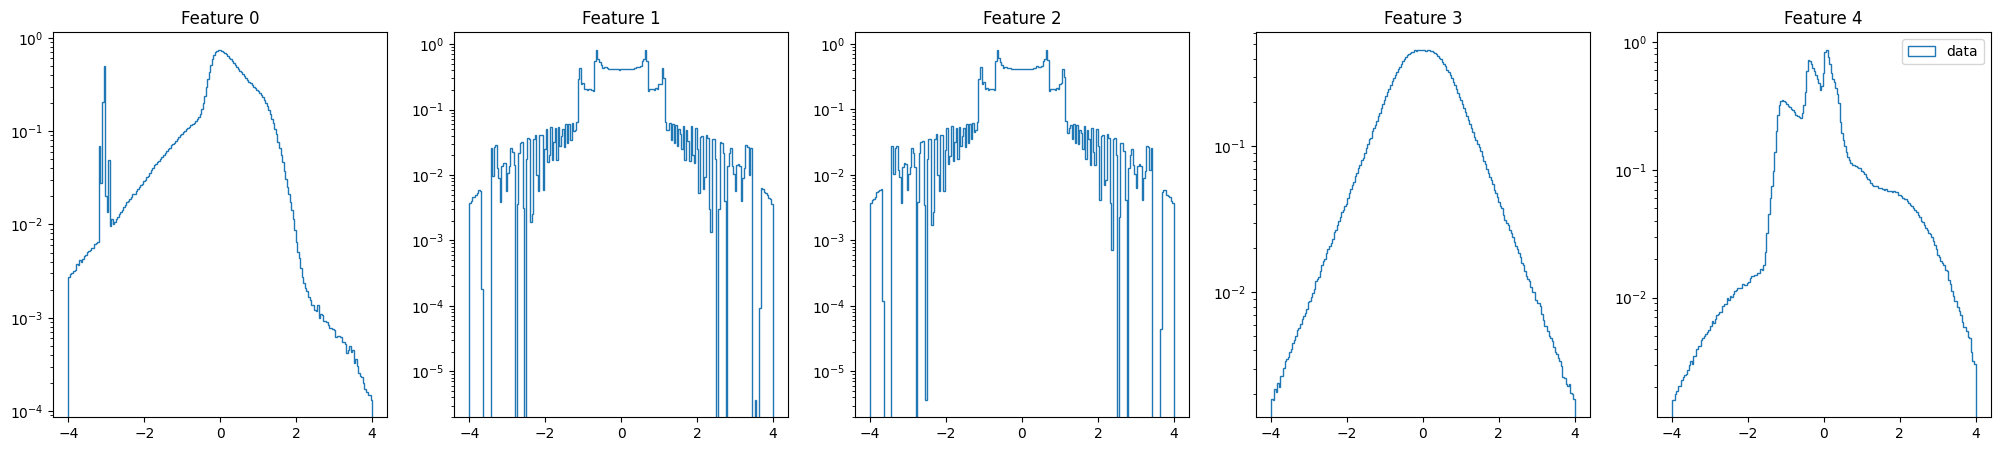

In [7]:
# load in data
collections_SimTrackerHit = [
 #   "InnerTrackerBarrelCollection",
   # "InnerTrackerBarrelCollectionConed",
   # "InnerTrackerEndcapCollection",
    #"InnerTrackerEndcapCollectionConed", 
    "OuterTrackerBarrelCollection",     
   # "OuterTrackerBarrelCollectionConed",
   # "OuterTrackerEndcapCollection",  
   # "OuterTrackerEndcapCollectionConed",
  #  "VertexBarrelCollection",   
   # "VertexBarrelCollectionConed",   
  #  "VertexEndcapCollection",
   # "VertexEndcapCollectionConed",
]


data = []
context = []

for i, collection in enumerate(collections_SimTrackerHit): # TODO coned too?

    tmp_data = np.load(f"/pscratch/sd/r/rmastand/muon/npys/{collection}_SimTrackerHit.npy")
    tmp_context = int(i)*np.ones((tmp_data.shape[0],1))
    context.append(tmp_context)
    data.append(tmp_data[:int(len(tmp_data)*1)])


data = np.vstack(data)[:,[0,2,3,4,5]]
N_FEATURES = data.shape[1]
print("Data shape:", data.shape)


data = preprocess_data(data, ".")


def sample_data(batch_size, device):
    indices = np.random.choice(range(len(data)), size = batch_size)
    return torch.tensor(data[indices], device = device).float()



plot_data({"data": data})

### Conditional Flow Matching

First we implement the basic conditional flow matching. As in the paper, we have
$$
\begin{align}
z &= (x_0, x_1) \\
q(z) &= q(x_0)q(x_1) \\
p_t(x | z) &= \mathcal{N}(x | t * x_1 + (1 - t) * x_0, \sigma^2) \\
u_t(x | z) &= x_1 - x_0
\end{align}
$$
When $\sigma = 0$ this is equivalent to zero-steps of rectified flow. We find that small $\sigma$ helps to regularize the problem ymmv.

In [8]:
from torch.utils.data import DataLoader


def run_flow_model(model, FM, name):

    model = model.to(device)

    # Assuming you have your model defined as 'model'
    num_params = count_parameters(model)
    print(f"Number of trainable parameters: {num_params}")
    

    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    losses = []


    train_loader = torch.utils.data.DataLoader(data, 
                                               batch_size=BATCH_SIZE, 
                                               shuffle=True, 
                                               num_workers = 8, 
                                               pin_memory = True, 
                                              drop_last=True)


    for k in range(N_EPOCHS):

        epoch_losses = []

        pbar = tqdm(
            train_loader,
            desc="Batches",
            leave=False,
        )
        
        for x1 in pbar:
            optimizer.zero_grad()
    
            x0 = torch.normal(size=(BATCH_SIZE, N_FEATURES), mean=0.0, std=1.0).to(device)
            x1 = x1.float().to(device)
            t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)
    
            vt = model(torch.cat([xt, t[:, None]], dim=-1))
            loss = torch.mean((vt - ut) ** 2)
            epoch_losses.append(loss.item())
    
            loss.backward()
            optimizer.step()

            pbar.set_postfix(loss=f"{loss.item():.3e}, epoch {k}")

        losses.append(np.mean(epoch_losses))

        if (k + 1) % PLOT_EPOCH_INTERVAL == 0:
            node = NeuralODE(
                torch_wrapper(model), solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4
            )

            plt.figure()
            plt.plot(losses)
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.savefig(f"{name}_losses")
            #plt.show()
            
            with torch.no_grad():
                traj = node.trajectory(
                    torch.normal(size=(N_SAMPLE, N_FEATURES), mean=0.0, std=1.0).to(device),
                    t_span=torch.linspace(0, 1, 100),
                )

                loc_data_dict = {"data": data,
                        "generated": traj[-1].cpu().numpy()}
                plot_data(loc_data_dict)
                plt.savefig(f"{name}_hists")
                #plt.show()

                for key in loc_data_dict.keys():
                    fig_samp, axes_samp = corner_hist2d(
                        loc_data_dict[key],
                        feature_labels=[f"feature {i}" for i in range(N_FEATURES)],
                        bins_dict={i: np.linspace(-5, 5, 50) for i in range(N_FEATURES)},
                        log_dims=(0, 4),
                        title= key,
                    )
                    plt.savefig(f"{name}_corner_{key}")
                    #plt.show()

    torch.save(model, f"{savedir}/{name}.pt")

In [9]:
flow_model_dicts = {
  #  "ConditionalFlowMatcher": {
   #     "model": MLP(dim=N_FEATURES, time_varying=True),
   #     "FM": ConditionalFlowMatcher(sigma=0.1),
   #     "name": "CFM_sigma01"
  #  },
    "ExactOptimalTransportConditionalFlowMatcher": {
        "model": MLP(dim=N_FEATURES, time_varying=True),
        "FM": ExactOptimalTransportConditionalFlowMatcher(sigma=0.1),
        "name": "EOTCFM_sigma0.1"
  },
    "SchrodingerBridgeConditionalFlowMatcher":{
        "model": MLP(dim=N_FEATURES, time_varying=True),
        "FM": SchrodingerBridgeConditionalFlowMatcher(sigma=0.5, ot_method="exact"),
        "name": "SBCFM_sigma0.5_exact"
    },
  #  "VariancePreservingConditionalFlowMatcher":{
  #     "model": MLP(dim=N_FEATURES, time_varying=True),
  #      "FM": VariancePreservingConditionalFlowMatcher(sigma=0.1),
  #      "name": "VPCFM_sigma01"
  #  }

}

for flow_model_key in flow_model_dicts.keys():
    print("Running flow model:", flow_model_key)

    model = flow_model_dicts[flow_model_key]["model"]
    fm    = flow_model_dicts[flow_model_key]["FM"]

    
    run_flow_model(
        model,
        fm,
        flow_model_dicts[flow_model_key]["name"],
    )

    del model
    del fm
    #del flow_model_dicts[flow_model_key]

    torch.cuda.empty_cache()
    torch.cuda.synchronize()


Running flow model: ExactOptimalTransportConditionalFlowMatcher
Number of trainable parameters: 531461


KeyboardInterrupt: 

### Action Matching (Neklyudov et al. 2022)

Next we try a variant called action matching. Here we parametrize the velocity field $v_\theta(t, x)$ as $\nabla s_\theta(t, x)$ where $s_\theta(t, x): \mathbb{R} \times \mathbb{R}^d \to \mathbb{R}$ is interpreted as the **action**. This is an interesting parameterization because of its link with optimal transport. Namely this velocity performs instantaneous optimal transport flow over $p_t(x)$. This is slightly different than optimal transport between marginals, but is also quite interesting. Action matching can be summarized in the following way:
$$
\begin{align}
z &= (x_0, x_1) \\
q(z) &= q(x_0)q(x_1) \\
p_t(x | z) &= \mathcal{N}(x | (1-t) x_0 + t x_1, \sigma^2)\\
L_{AM}(\theta) &= s_\theta(0, x_0) - s_\theta(1, x_1) + \frac{1}{2} \| \nabla_x s_\theta(t, x_t)\|^2 + \frac{\partial}{\partial t} s_\theta(t, x_t)
\end{align}
$$
Note that the authors again consider $\sigma = 0$ (i.e. a Dirac around $\mu_t$) but we keep the general form for consistency assuming that $\mathcal{N}(x | \mu_t, 0)$ is a degenerate Dirac centered at $\mu_t$. Our standard parameterization seems to be more difficult to fit with this loss (3-layer MLP with width 64 and SELU activations). It's unclear to me why this is the case, but as suggested in their repo using ReLU, Swish, Swish activations works much better.

In [11]:
from torchcfm.models.models import GradModel





def run_flow_model_action_matching(action, name):
    # %%time
    model = GradModel(action)
    model = model.to(device)
    num_params = count_parameters(model)
    print(f"Number of trainable parameters: {num_params}")
    optimizer = torch.optim.Adam(action.parameters(), lr=LEARNING_RATE)
    losses = []

    train_loader = torch.utils.data.DataLoader(data, 
                                               batch_size=BATCH_SIZE, 
                                               shuffle=True, 
                                               num_workers = 8, 
                                               pin_memory = True, 
                                              drop_last=True)

    for k in range(N_EPOCHS):

        pbar = tqdm(
        train_loader,
        desc="Batches",
        leave=False,
    )

        epoch_losses = []

        for x1 in pbar:
        
            optimizer.zero_grad()
            t = torch.rand(BATCH_SIZE, 1).requires_grad_(True).to(device)
            x0 = torch.normal(size=(BATCH_SIZE, N_FEATURES), mean=0.0, std=1.0).to(device)
            x1 = x1.float().to(device)
            xt = (t * x1 + (1 - t) * x0).detach().requires_grad_(True)
            st = torch.sum(action(torch.cat([xt, t], dim=-1)))
            dsdx, dsdt = torch.autograd.grad(st, (xt, t), create_graph=True, retain_graph=True)
            #xt.requires_grad, t.requires_grad = False, False
            xt = xt.detach()
            t = t.detach()
            a0 = action(torch.cat([x0, torch.zeros(BATCH_SIZE, 1).to(device)], dim=-1))
            a1 = action(torch.cat([x1, torch.ones(BATCH_SIZE, 1).to(device)], dim=-1))
            loss = a0 - a1 + 0.5 * (dsdx**2).sum(1, keepdims=True) + dsdt
            loss = loss.mean()
            epoch_losses.append(loss.item())
            loss.backward()
            optimizer.step()

            pbar.set_postfix(loss=f"{loss.item():.3e}, epoch {k}")

        losses.append(np.mean(epoch_losses))

        if (k + 1) % PLOT_EPOCH_INTERVAL == 0:
           
            plt.figure()
            plt.plot(losses)
            plt.xlabel("Epoch")
            plt.ylabel("Loss")
            plt.savefig(f"{name}_losses")
            #plt.show()

            node = NeuralODE(
                torch_wrapper(model), solver="euler", sensitivity="adjoint", atol=1e-4, rtol=1e-4
            )
            # with torch.no_grad():
            traj = node.trajectory(
                torch.normal(size=(N_SAMPLE, N_FEATURES), mean=0.0, std=1.0).to(device),
                t_span=torch.linspace(0, 1, 100),
            ).detach()
            loc_data_dict = {"data": data,
                        "generated": traj[-1].cpu().numpy()}
            plot_data(loc_data_dict)
            plt.savefig(f"{name}_hists")
            

            for key in loc_data_dict.keys():
                fig_samp, axes_samp = corner_hist2d(
                    loc_data_dict[key],
                    feature_labels=[f"feature {i}" for i in range(N_FEATURES)],
                    bins_dict={i: np.linspace(-5, 5, 50) for i in range(N_FEATURES)},
                    log_dims=(0, 4),
                    title= key,
                )
                plt.savefig(f"{name}_corner_{key}")
                #plt.show()
    torch.save(model, f"{savedir}/{name}.pt")

In [12]:

flow_model_action_dicts= {
    "MLP": {
        "action":  MLP(dim=N_FEATURES, out_dim=1, time_varying=True),
        "name": "action"
    }
}

for flow_model_key in flow_model_action_dicts.keys():
    print("Running flow model action matching:", flow_model_key)
    run_flow_model_action_matching(
        flow_model_action_dicts[flow_model_key]["action"],
        flow_model_action_dicts[flow_model_key]["name"],
    )

Running flow model action matching: MLP
Number of trainable parameters: 529409


KeyboardInterrupt: 